# Segmentation attempt
## Run on Dwarp

In [1]:
import numpy as np
import numpy
import os
#import scipy.ndimage       as nd
#from scipy.ndimage import zoom, generic_gradient_magnitude
from pathlib import Path
# import myVTKPythonLibrary as myvtk
# from pom_funkce_VTK import numpy2VTK
# from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from scipy import ndimage
import copy 
from skimage import measure



base = "/Users/skardova/Documents/MRI_data/2026-Eyes-project/Trial2/"

folder = "VTI_shared_view"

img = numpy.load(base + folder + os.sep + "rot-view_2_cut.npy")
img_shape = img.shape

print("img shape = ", img_shape)

factor = 3

img = ndimage.median_filter(img, size=2)
img = ndimage.zoom(img, 1/factor)

print("img shape = ", img.shape)



img shape =  (138, 130, 140)
img shape =  (46, 43, 47)


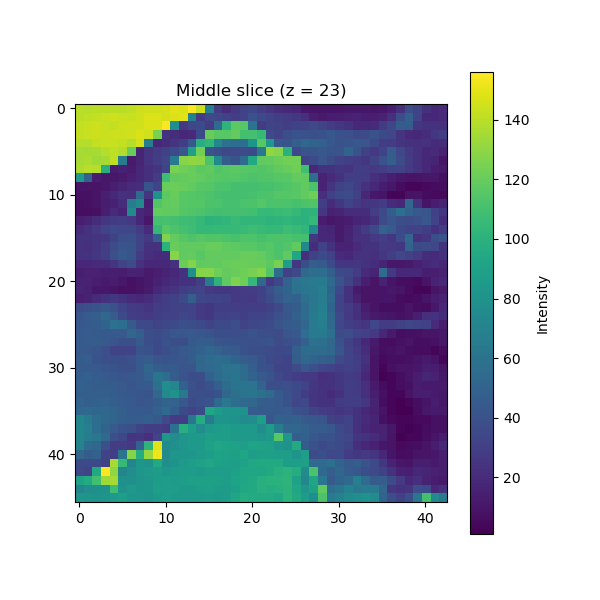

In [2]:
# %matplotlib inline

%matplotlib widget


import matplotlib.pyplot as plt

mid_z = img.shape[2] // 2

clicked_points = []  # ← stored here

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(img[:, :, mid_z], cmap="viridis")
ax.set_title(f"Middle slice (z = {mid_z})")

# add colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Intensity")  # optional label

def onclick(event):
    if event.inaxes != ax:
        return

    x = int(round(event.xdata))
    y = int(round(event.ydata))

    if 0 <= y < img.shape[0] and 0 <= x < img.shape[1]:
        # point = (x, y, mid_z)
        point = (y, x, mid_z)   # row, col, z

        clicked_points.append(point)

        print(f"Stored click #{len(clicked_points)}: {point}")

        # optional: mark the point visually
        ax.plot(x, y, 'r+', markersize=10)
        fig.canvas.draw_idle()

cid = fig.canvas.mpl_connect('button_press_event', onclick)

plt.show()

In [3]:
def get_6_neighbors(coords, shape):
    """
    coords are (row, col, z)
    shape is img.shape = (rows, cols, depth)
    """
    neighbors = set()

    offsets = [(-1, 0, 0), (1, 0, 0),
               (0, -1, 0), (0, 1, 0),
               (0, 0, -1), (0, 0, 1)]

    nrows, ncols, nz = shape

    for r, c, z in coords:
        for dr, dc, dz in offsets:
            nr, nc, nz_ = r + dr, c + dc, z + dz
            if (1 <= nr < nrows-1 and
                1 <= nc < ncols-1 and
                1 <= nz_ < nz-1):
                neighbors.add((nr, nc, nz_))

    return list(neighbors)

def gorow(current_points, img, checked_points):
    added = 0

    # img[p] is now CORRECT because p = (row, col, z)
    values = [img[p] for p in current_points]

    current_mean = np.mean(values)
    current_min = np.min(values)
    current_max = np.max(values)
    current_std = np.std(values)

    print(" current min, max = ", current_min, current_max)
    print(" current mean = ", current_mean)

    potential_points = get_6_neighbors(current_points, img.shape)

    for p in potential_points:

        if p in current_points or p in checked_points:
            continue

        r, c, z = p
        crit_1 = crit_2 = crit_3 = 0

        # ---- gradient (central difference, axis-correct) ----
        gx = (img[r, c+1, z] - img[r, c-1, z]) / 2
        gy = (img[r+1, c, z] - img[r-1, c, z]) / 2
        gz = (img[r, c, z+1] - img[r, c, z-1]) / 2

        grad_norm = np.sqrt(gx**2 + gy**2 + gz**2)

        # ---- local homogeneity ----
        local_window = img[
            r-1:r+2,
            c-1:c+2,
            z-1:z+2
        ]

        crit_1 = np.abs(img[p] - current_mean) / current_mean
        crit_2 = grad_norm / img[p]
        crit_3 = np.std(local_window) / current_std

        if crit_1 < 0.5 and crit_2 < 0.5:  # optionally add crit_3
            current_points.append(p)
            added += 1
        else:
            checked_points.append(p)

    return current_points, added


print("Initial n. points = ", len(clicked_points))

growing = True

current_points = copy.deepcopy(clicked_points)
checked_points = []


while growing:
    current_points, added = gorow(current_points, img, checked_points)
    if added>0:
        growing = True
    else:
        growing = False

    print("Next n. points = ", len(current_points))
    print()

print("Final n. points = ", len(current_points))


Initial n. points =  0


/opt/homebrew/Caskroom/miniconda/base/envs/dwarp/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/homebrew/Caskroom/miniconda/base/envs/dwarp/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: zero-size array to reduction operation minimum which has no identity

In [ ]:
mask = np.zeros(img.shape, dtype=np.uint8)
for r, c, z in current_points:
    mask[r, c, z] = 1


mask = ndimage.zoom(mask, factor)
mask[mask<0.5]=0
mask[mask>=0.5]=1


numpy.save(base + folder + os.sep + 'segmentations/Test-1-labels_mask', mask)


In [ ]:
from scipy import ndimage
from nanomesh import Image
from nanomesh import Volume
from nanomesh import Mesher





vol = Image(mask)


mesher = Mesher(vol)
mesher.generate_contour()

mesher.contour.region_markers

mesh = mesher.tetrahedralize(opts='-pAq -a50')


tetra_mesh = mesh.get('tetra')
tetra_mesh.write(base + folder + os.sep + 'segmentations/Test-1-cells.vtk')




In [ ]:
import meshio


mesh = meshio.read(base + folder + os.sep + 'segmentations/Test-1-cells.vtk')



points = mesh.points
cells = mesh.cells
cell_data = mesh.cell_data


new_cells = []
new_cell_data = {}

# Loop over each cell block (e.g., triangle, tetra, etc.)
for i, cell_block in enumerate(cells):
    cell_type = cell_block.type
    cell_array = cell_block.data
    
    # Get corresponding cell data array
    # (assumes only one data name exists)
    data_name = list(cell_data.keys())[0]
    tags = cell_data[data_name][i]

    # Select only cells with tag == 2
    mask = tags == 2
    filtered_cells = cell_array[mask]
    filtered_tags = tags[mask]

    if len(filtered_cells) > 0:
        new_cells.append((cell_type, filtered_cells))
        
        if data_name not in new_cell_data:
            new_cell_data[data_name] = []
        new_cell_data[data_name].append(filtered_tags)

# Create new mesh
new_mesh = meshio.Mesh(
    points=points,
    cells=new_cells,
    cell_data=new_cell_data
)

# Write mesh
meshio.write(base + folder + os.sep + 'segmentations/Test-1-cells_filtered.vtk', new_mesh)